In [57]:
# 基础输入输出
def basic_io_demo():
    """基础输入输出演示"""
    print("=== 基础输入输出演示 ===")

    # 模拟输入
    input_str = "1 2 3 4 5"
    print(f"模拟输入: '{input_str}'")

    # 读取单行多个数字
    data = list(map(int, input_str.split()))
    print(f"转换为列表: {data}")

    # 读取两个数字
    a, b = map(int, "10 20".split())
    print(f"两个数字: a={a}, b={b}")

    # 读取矩阵
    matrix_input = ["1 2 3", "4 5 6", "7 8 9"]
    matrix = []
    for line in matrix_input:
        row = list(map(int, line.split()))
        matrix.append(row)
    print(f"3x3矩阵: {matrix}")

    # 读取输入的两个数字
    # a, b = map(int, input("请输入两个数字: ").split())
    # print(f"两个数字: a={a}, b={b}")

    # # 读取输入的矩阵
    # matrix_input = input("请输入3x3矩阵: ")
    # matrix = []
    # for line in matrix_input.split("\n"):
    #     row = list(map(int, line.split()))
    #     matrix.append(row)
    # print(f"3x3矩阵: {matrix}")


basic_io_demo()
# a,b  = map(int, input("请输入两个数字: ").split())

=== 基础输入输出演示 ===
模拟输入: '1 2 3 4 5'
转换为列表: [1, 2, 3, 4, 5]
两个数字: a=10, b=20
3x3矩阵: [[1, 2, 3], [4, 5, 6], [7, 8, 9]]


## 卷积的输出高度和宽度

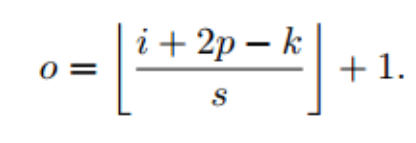

输出高度 = ⌊(输入高度 + 2× 垂直填充 - 卷积核高度) / 垂直步长⌋ + 1

输出宽度 = ⌊(输入宽度 + 2× 水平填充 - 卷积核宽度) / 水平步长⌋ + 1


In [58]:
# 在Jupyter中运行
# !pip uninstall numpy -y
# !pip install numpy

In [59]:
# 2D卷积实现
import numpy as np


def conv2d1(image: np.ndarray, kernel: np.ndarray):
    # 高宽，卷积的高和宽，填充的~，结果的~
    if isinstance(image, list):
        image = np.array(image)
    if isinstance(kernel, list):
        kernel = np.array(kernel)
    h, w = image.shape
    kh, kw = kernel.shape
    padh, padw = (kh - 1) // 2, (kw - 1) // 2

    # NOTE 要么使用填充并输出 (5, 5)，要么不使用填充输出 (3, 3)，但不能混合使用。

    # resh = h - kh + 1
    # resw = w - kw + 1
    resh = h
    resw = w
    # zeros的参数是一个表示数组维度的元祖
    output = np.zeros((resh, resw))

    padded_image = np.zeros((h + 2 * padh, w + 2 * padw))
    padded_image[padh : padh + h, padw : padw + w] = image

    # 默认stride为1
    for i in range(resh):
        for j in range(resw):
            # 计算得到填充后的全0图像
            sub_image = padded_image[i : i + kh, j : j + kw]
            output[i, j] = (sub_image * kernel).sum()
    return output


image = np.ones((5, 5))
kernel = np.ones((3, 3))
result = conv2d1(image, kernel)
print(result.shape)  # 输出: (3, 3)
print(result)  # 所有值都是9.0

(5, 5)
[[4. 6. 6. 6. 4.]
 [6. 9. 9. 9. 6.]
 [6. 9. 9. 9. 6.]
 [6. 9. 9. 9. 6.]
 [4. 6. 6. 6. 4.]]


NMS,非极大值抑制

用于图像检测，计算出不同边界框部分的 IOU,只保留其中最大的框,其他的边界框被舍弃掉,因为算法不知道一共有几个目标，只能看到一堆框，因此通过 IoU 的重叠程度来判断是否为同一目标。

计算交集区域：找到重叠区域的左上和右下坐标

计算各自面积：分别计算两个框的面积

计算并集区域：使用公式 面积 1 + 面积 2 - 交集

计算 IoU：交集 / 并集，加上小常数避免除零错误


In [60]:
def cal_IoU(box1, boxes):
    """
    box1: 单个边界框，格式 [x1, y1, x2, y2]
    boxes: 多个边界框，形状为 (N, 4) 的数组
    """
    x1 = np.maximum(box1[0], boxes[:, 0])
    y1 = np.maximum(box1[1], boxes[:, 1])
    x2 = np.minimum(box1[2], boxes[:, 2])
    y2 = np.minimum(box1[3], boxes[:, 3])
    print("x1, y1, x2, y2:", x1, y1, x2, y2)

    intersection = np.maximum(0, x2 - x1) * np.maximum(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    union = area1 + area2 - intersection
    print("intersection, union:", intersection, union)
    return intersection / (union + 1e-6)


def runIoU():
    box1 = [10, 10, 20, 20]
    boxes = [[5, 5, 15, 15], [10, 10, 20, 20], [15, 15, 25, 25]]
    boxes = np.array(boxes)  # 转换为 numpy 数组
    print(cal_IoU(box1, boxes))


def nms(boxes: np.ndarray, scores: np.ndarray, threshold=0.5):
    """
    boxes: 边界框，形状为 (N, 4) 的数组
    scores: 边界框对应的分数，形状为 (N,) 的数组
    threshold: 阈值
    """
    indices = np.argsort(scores)[::-1]  # 按分数从大到小排序，得到索引
    keep = []
    while indices.size > 0:
        current = indices[0]
        keep.append(current)
        if indices.size == 1:
            break
        current_box = boxes[current]
        # 计算当前边界框与其他边界框的 IoU
        overlap = cal_IoU(current_box, boxes[indices[1:]])
        # 保留 IoU 小于阈值的边界框的索引
        indices = indices[np.where(overlap <= threshold)[0] + 1]
    return keep


def runNMS():
    boxes = [[5, 5, 15, 15], [10, 10, 20, 20], [15, 15, 25, 25]]
    scores = [0.9, 0.8, 0.7]
    boxes = np.array(boxes)  # 转换为 numpy 数组
    scores = np.array(scores)
    keep = nms(boxes, scores, threshold=0.5)
    print(keep)


runNMS()

x1, y1, x2, y2: [10 15] [10 15] [15 15] [15 15]
intersection, union: [25  0] [175 200]
x1, y1, x2, y2: [15] [15] [20] [20]
intersection, union: [25] [175]
[0, 1, 2]


In [61]:
# 数据增强，包括随机裁剪和随机水平翻转
from typing import Tuple
import numpy as np


def random_crop(img: np.ndarray, size: Tuple[int, int]):
    h, w = img.shape[:2]
    th, tw = size
    top = np.random.randint(0, h - th)
    left = np.random.randint(0, w - tw)
    bottom = top + th
    right = left + tw
    img = img[top:bottom, left:right]
    return img


def random_flip(img: np.ndarray, p: float = 0.5):
    if np.random.rand() < p:
        img = img[:, ::-1]
    return img


def run_random_crop(img: np.ndarray, size: Tuple[int, int]):
    img = random_crop(img, size)
    img = random_flip(img)
    return img


img = np.random.rand(224, 224, 3)
print(img.shape)
size = (128, 128)
img = run_random_crop(img, size)
print(img.shape)

(224, 224, 3)
(128, 128, 3)


In [62]:
def numpy_demo():
    """numpy使用演示"""
    print("\n=== Numpy演示 ===")

    # 创建矩阵
    ones = np.ones((2, 3))
    zeros = np.zeros((3, 2))
    identity = np.eye(3)
    random_mat = np.random.rand(2, 2)

    print(f"全1矩阵:\n{ones}")
    print(f"全0矩阵:\n{zeros}")
    print(f"单位矩阵:\n{identity}")
    print(f"随机矩阵:\n{random_mat}")

    # 矩阵运算
    A = np.array([[1, 2], [3, 4]])
    B = np.array([[5, 6], [7, 8]])
    C = np.dot(A, B)  # 矩阵乘法
    print(f"矩阵乘法:\n{A} × \n{B} = \n{C}")

    # 广播机制
    a = np.array([1, 2, 3])
    b = np.array([[1], [2], [3]])
    result = a + b
    print(f"广播相加:\n{a} + \n{b} = \n{result}")

    # 索引和切片
    arr = np.random.rand(4, 4)
    print(f"原始矩阵:\n{arr}")
    print(f"切片 [1:3, 1:3]:\n{arr[1:3, 1:3]}")


numpy_demo()


=== Numpy演示 ===
全1矩阵:
[[1. 1. 1.]
 [1. 1. 1.]]
全0矩阵:
[[0. 0.]
 [0. 0.]
 [0. 0.]]
单位矩阵:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
随机矩阵:
[[0.11945536 0.1801875 ]
 [0.66434204 0.09669381]]
矩阵乘法:
[[1 2]
 [3 4]] × 
[[5 6]
 [7 8]] = 
[[19 22]
 [43 50]]
广播相加:
[1 2 3] + 
[[1]
 [2]
 [3]] = 
[[2 3 4]
 [3 4 5]
 [4 5 6]]
原始矩阵:
[[0.79917826 0.01240901 0.75098508 0.3988824 ]
 [0.43916574 0.77601073 0.9143862  0.58548749]
 [0.22896832 0.49980994 0.58003487 0.95484754]
 [0.95483313 0.63016238 0.69005998 0.08608875]]
切片 [1:3, 1:3]:
[[0.77601073 0.9143862 ]
 [0.49980994 0.58003487]]


In [63]:
def create_test_matrix(rows, cols):
    """创建测试矩阵"""
    return [[i * cols + j + 1 for j in range(cols)] for i in range(rows)]


def print_matrix(matrix, name="矩阵"):
    """美化打印矩阵"""
    print(f"{name}:")
    for row in matrix:
        print(row)
    print()


# create_test_matrix(3, 4)
print_matrix(create_test_matrix(3, 4))

矩阵:
[1, 2, 3, 4]
[5, 6, 7, 8]
[9, 10, 11, 12]



下面是自己实现的矩阵转置,矩阵乘法,矩阵求逆的 python 代码


In [64]:
def matrix_transpose(matrix):
    """矩阵转置"""
    return [[matrix[j][i] for j in range(len(matrix))] for i in range(len(matrix[0]))]


def matrix_multiply(A, B):
    """矩阵乘法 (自己实现，不用numpy)"""
    if len(A[0]) != len(B):
        raise ValueError("矩阵维度不匹配")

    n, m, p = len(A), len(A[0]), len(B[0])
    result = [[0] * p for _ in range(n)]

    for i in range(n):
        for j in range(p):
            for k in range(m):
                result[i][j] += A[i][k] * B[k][j]

    return result


def matrix_inverse_2x2(matrix):
    """2x2矩阵求逆"""
    if len(matrix) != 2 or len(matrix[0]) != 2:
        raise ValueError("只支持2x2矩阵")

    a, b, c, d = matrix[0][0], matrix[0][1], matrix[1][0], matrix[1][1]
    det = a * d - b * c

    if det == 0:
        raise ValueError("矩阵不可逆")

    return [[d / det, -b / det], [-c / det, a / det]]


matrix1 = [[1, 2], [3, 4]]
matrix2 = [[5, 6], [7, 8]]

print(" matrix1 has been transposed to :\n", matrix_transpose(matrix1))
print(" matrix2 has been multiplied by matrix1 :\n", matrix_multiply(matrix1, matrix2))
print(" matrix1 has been inverted to :\n", matrix_inverse_2x2(matrix1))

 matrix1 has been transposed to :
 [[1, 3], [2, 4]]
 matrix2 has been multiplied by matrix1 :
 [[19, 22], [43, 50]]
 matrix1 has been inverted to :
 [[-2.0, 1.0], [1.5, -0.5]]


In [65]:
# 通过np的函数实现矩阵转置，矩阵乘法,矩阵求逆
import numpy as np

# 矩阵转置
a = np.array([[1, 2, 3], [4, 5, 6]])
print(a.T)

# 矩阵乘法
b = np.array([[1, 2], [3, 4], [5, 6]])
c = np.array([[7, 8], [9, 10]])
print(np.dot(b, c))  # 矩阵乘法

# 矩阵求逆
d = np.array([[1, 2], [3, 4]])
print(np.linalg.inv(d))  # 矩阵求逆

[[1 4]
 [2 5]
 [3 6]]
[[ 25  28]
 [ 57  64]
 [ 89 100]]
[[-2.   1. ]
 [ 1.5 -0.5]]


图像处理算法


In [66]:
import math
import cv2


def grayscale_conversion(image):
    """RGB转灰度图"""
    # 假设image是3D列表 [height][width][rgb]
    height, width = len(image), len(image[0])
    gray = [[0] * width for _ in range(height)]

    for i in range(height):
        for j in range(width):
            r, g, b = image[i][j]
            # 标准灰度公式
            gray[i][j] = 0.299 * r + 0.587 * g + 0.114 * b  # 标准灰度公式

    return gray


def image_thresholding(image, threshold=128):
    """图像二值化"""
    height, width = len(image), len(image[0])
    binary = [[0] * width for _ in range(height)]

    for i in range(height):
        for j in range(width):
            binary[i][j] = 255 if image[i][j] >= threshold else 0

    return binary


def sobel_edge_detection(image):
    """Sobel边缘检测"""
    sobel_x = [[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]]
    sobel_y = [[-1, -2, -1], [0, 0, 0], [1, 2, 1]]

    grad_x = conv2d1(image, sobel_x)
    grad_y = conv2d1(image, sobel_y)

    height, width = len(image), len(image[0])
    magnitude = [[0] * width for _ in range(height)]

    for i in range(height):
        for j in range(width):
            magnitude[i][j] = math.sqrt(grad_x[i][j] ** 2 + grad_y[i][j] ** 2)

    return magnitude


def run_Image_nums():
    image = [
        [[255, 255, 255], [255, 0, 0], [255, 255, 255]],
        [[255, 0, 0], [0, 0, 0], [255, 0, 0]],
        [[255, 255, 255], [255, 0, 0], [255, 255, 255]],
    ]

    for i in image:
        print(i)  # 打印原始图像
    # print(image)
    print("=" * 50)
    gray = grayscale_conversion(image)
    for i in gray:
        print(i)  # 打印灰度图像
    print("=" * 50)
    binary = image_thresholding(gray, 128)
    for i in binary:
        print(i)  # 打印二值化图像
    print("=" * 50)
    # print(binary)
    magnitude = sobel_edge_detection(gray)
    for i in magnitude:
        print(i)  # 打印边缘强度图像
    # print(magnitude)


def run_Image_image():
    img = cv2.imread("./wen.jpg")
    if img is None:
        print("无法加载图像")
        return

    # 获取原始图像尺寸
    height, width = img.shape[:2]
    print(f"原始图像尺寸: {width}x{height}")

    # 创建可调整大小的窗口
    cv2.namedWindow("image", cv2.WINDOW_NORMAL)

    # 设置窗口初始大小（保持宽高比）
    # 例如设置宽度为800，高度按比例计算
    target_width = 800
    target_height = int(height * (target_width / width))
    cv2.resizeWindow("image", target_width, target_height)

    cv2.imshow("image", img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # 灰度转换
    gray = grayscale_conversion(img)
    cv2.imshow("gray", np.array(gray, dtype=np.uint8))
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # 二值化
    ret, binary = cv2.threshold(gray, 128, 255, cv2.THRESH_BINARY)
    cv2.imshow("binary", binary)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

    # 自己的图像二值化
    # binary = image_thresholding(gray, 128)
    # cv2.imshow("binary", np.array(binary, dtype=np.uint8))
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

    # Sobel边缘检测
    sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = cv2.magnitude(sobel_x, sobel_y)
    cv2.imshow("magnitude", magnitude)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


# run_Image_image()

In [67]:
# 机器学习基础
def euclidean_distance(point1, point2):
    """计算欧几里得距离"""
    res = math.sqrt(sum((x - y) ** 2 for x, y in zip(point1, point2)))
    return res


def manhattan_distance(point1, point2):
    """计算曼哈顿距离"""
    return sum(abs(x - y) for x, y in zip(point1, point2))


point1 = (0, 0)
point2 = (3, 4)
print(euclidean_distance(point1, point2))
print(manhattan_distance(point1, point2))

5.0
7


预测结果: [0, 1, 0, 0]
准确率: 0.75


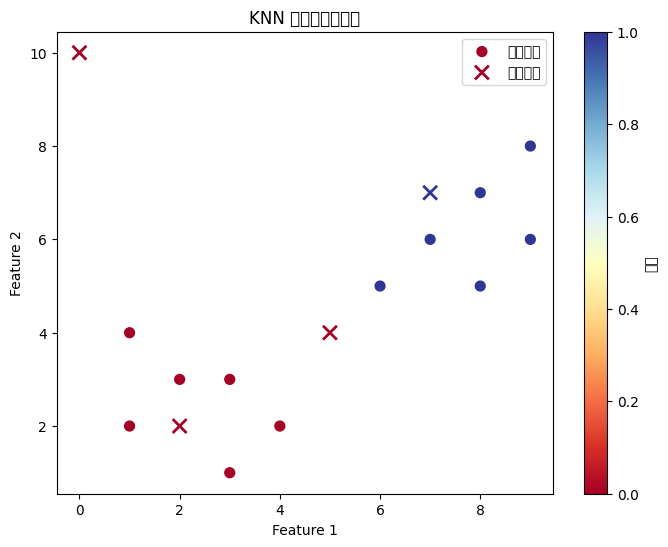

In [68]:
import numpy as np
import matplotlib.pyplot as plt


# def euclidean_distance(a, b):
#     """计算欧氏距离"""
#     return np.sqrt(np.sum((a - b) ** 2))


def visually_show_data(X_train, y_train, X_test=None, y_pred=None):
    """可视化展示数据（包含训练集和测试集）"""
    plt.figure(figsize=(8, 6))

    # 绘制训练集
    plt.scatter(
        X_train[:, 0], X_train[:, 1], c=y_train, s=50, cmap="RdYlBu", label="训练数据"
    )

    # 绘制测试集（如果存在）
    if X_test is not None and y_pred is not None:
        X_test = np.array(X_test)
        plt.scatter(
            X_test[:, 0],
            X_test[:, 1],
            c=y_pred,
            s=100,
            cmap="RdYlBu",
            marker="x",
            linewidths=2,
            label="测试数据",
        )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("KNN 数据分布可视化")
    plt.colorbar(label="类别")
    plt.legend()
    plt.show()


def k_nearest_neighbors(X_train, y_train, X_test, k=3):
    """K近邻算法实现"""
    predictions = []
    for test_point in X_test:
        # 计算距离
        distances = [euclidean_distance(test_point, x) for x in X_train]
        # 获取最近的k个邻居的标签
        k_indices = np.argsort(distances)[:k]
        k_nearest_labels = [y_train[i] for i in k_indices]
        # 多数投票
        prediction = max(set(k_nearest_labels), key=k_nearest_labels.count)
        predictions.append(prediction)
    return predictions


# 训练数据
X_train = np.array(
    [
        [1, 2],
        [1, 4],
        [2, 3],
        [3, 1],
        [3, 3],
        [4, 2],
        [6, 5],
        [7, 6],
        [8, 5],
        [8, 7],
        [9, 6],
        [9, 8],
    ]
)
y_train = np.array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1])

# 测试数据
X_test = np.array([[2, 2], [7, 7], [5, 4], [0, 10]])
y_test = np.array([0, 1, 0, 1])  # 真实标签（用于验证）

# 预测
predictions = k_nearest_neighbors(X_train, y_train, X_test, k=3)
print("预测结果:", predictions)

# 计算准确率
accuracy = np.mean(predictions == y_test)
print(f"准确率: {accuracy:.2f}")

# 可视化（包含测试点）
visually_show_data(X_train, y_train, X_test, predictions)

In [69]:
import numpy as np
import random


def kmeans_clustering(data, k=3, max_iterations=100):
    """K-means聚类算法（修正版）
    data: 待聚类的数据，格式为 [[x1, y1], [x2, y2],...]
    k: 聚类中心的个数
    max_iterations: 最大迭代次数
    返回值：
    centers: 聚类中心，格式为 [[x1, y1], [x2, y2],...]
    clusters: 各数据点所属的簇，格式为 [[[x1, y1], [x2, y2],...], [[x3, y3], [x4, y4],...],...]
    """
    data = np.array(data)  # 确保数据是 NumPy 数组
    # 随机初始化中心点（从数据中随机选择 k 个点）
    centers = data[np.random.choice(len(data), k, replace=False)]

    for _ in range(max_iterations):
        # 分配点到最近的簇
        clusters = [[] for _ in range(k)]
        for point in data:
            distances = [euclidean_distance(point, center) for center in centers]
            cluster_idx = np.argmin(distances)  # 更高效的索引查找
            clusters[cluster_idx].append(point)

        # 更新中心点
        new_centers = []
        for cluster in clusters:
            if cluster:
                new_center = np.mean(cluster, axis=0)  # 直接用 NumPy 计算均值
                new_centers.append(new_center)
            else:
                new_centers.append(random.choice(data))  # 避免空簇

        # 检查收敛（中心点是否变化）
        if np.allclose(centers, new_centers, atol=1e-6):
            break

        centers = np.array(new_centers)

    return centers, clusters


# 测试数据
data = [[1, 2], [1, 4], [1, 0], [4, 2], [4, 4], [4, 0]]
centers, clusters = kmeans_clustering(data, k=2)
print("中心点:")
print(centers)
print("聚类结果:")
print(clusters)

中心点:
[[3.         0.66666667]
 [2.         3.33333333]]
聚类结果:
[[array([1, 0]), array([4, 2]), array([4, 0])], [array([1, 2]), array([1, 4]), array([4, 4])]]


In [74]:
import numpy as np
import random


def euclidean_distance(point1, point2):
    """计算两点之间的欧几里得距离"""
    return np.sqrt(np.sum((np.array(point1) - np.array(point2)) ** 2))


def kmeans_clustering(data, k=3, max_iterations=100):
    """K-means聚类算法（修正版）

    K-means是一种无监督学习算法，用于将数据点划分为k个簇。
    算法通过迭代优化，使得同一簇内的数据点尽可能相似，不同簇的数据点尽可能不同。

    参数:
    data: 待聚类的数据，格式为 [[x1, y1], [x2, y2],...] 或 numpy数组
    k: 聚类中心的个数，需要预先指定
    max_iterations: 最大迭代次数，防止无限循环

    返回值:
    centers: 最终的聚类中心坐标，格式为 [[x1, y1], [x2, y2],...]
    clusters: 各数据点所属的簇，每个簇包含该簇的所有数据点
    """

    # 步骤1: 数据预处理 - 确保输入数据为NumPy数组格式
    # 这样可以利用NumPy的向量化操作提高计算效率
    data = np.array(data)

    # 步骤2: 初始化聚类中心
    # 从数据中随机选择k个不同的点作为初始聚类中心
    # 这种初始化方法称为"Forgy"方法
    centers = data[np.random.choice(len(data), k, replace=False)]

    print("初始聚类中心:")
    print(centers)
    print("-" * 50)

    # 步骤3: 开始迭代优化过程
    for iteration in range(max_iterations):
        print(f"迭代次数: {iteration + 1}")

        # 步骤3.1: 分配阶段 - 将每个数据点分配到最近的聚类中心
        # 创建k个空列表来存储每个簇的数据点
        clusters = [[] for _ in range(k)]

        # 遍历所有数据点
        for point in data:
            # 计算当前点到所有聚类中心的距离
            distances = [euclidean_distance(point, center) for center in centers]

            # 找到距离最近的聚类中心的索引
            cluster_idx = np.argmin(distances)

            # 将该点分配到对应的簇中
            clusters[cluster_idx].append(point)

        print("当前簇分配完成")

        # 步骤3.2: 更新阶段 - 重新计算每个簇的聚类中心
        new_centers = []
        for i, cluster in enumerate(clusters):
            if cluster:  # 如果簇不为空
                # 计算簇内所有点的均值作为新的聚类中心
                # 均值点使得簇内点到中心的距离平方和最小
                new_center = np.mean(cluster, axis=0)
                new_centers.append(new_center)
                print(f"簇{i}的新中心: {new_center} (基于{len(cluster)}个点)")
            else:
                # 处理空簇情况：随机选择一个数据点作为新中心
                # 这可以避免某些簇没有数据点的问题
                new_center = random.choice(data)
                new_centers.append(new_center)
                print(f"簇{i}为空，随机选择新中心: {new_center}")

        # 步骤3.3: 收敛检查 - 判断聚类中心是否不再变化
        # 如果新旧中心点非常接近（在容差范围内），则认为算法已收敛
        if np.allclose(centers, new_centers, atol=1e-6):
            print("算法已收敛！中心点不再变化。")
            break

        # 更新聚类中心为新的中心点，准备下一次迭代
        centers = np.array(new_centers)
        print(f"更新后的中心点: {centers}")
        print("-" * 30)

    # 步骤4: 返回最终结果
    # 经过多次迭代后，算法找到相对稳定的聚类结果
    return centers, clusters


# 测试数据：简单的二维数据点，明显可以分为2个簇
# 前3个点靠近(1,2)区域，后3个点靠近(4,2)区域
data = [[1, 2], [1, 4], [1, 0], [4, 2], [4, 4], [4, 0]]

print("K-means聚类算法演示")
print("=" * 50)
print("输入数据:")
for i, point in enumerate(data):
    print(f"点{i+1}: {point}")

print("\n开始聚类过程...")
print("=" * 50)

# 执行K-means聚类，k=2表示我们希望将数据分为2个簇
centers, clusters = kmeans_clustering(data, k=2)

print("\n" + "=" * 50)
print("最终聚类结果:")
print("=" * 50)

# 输出最终的聚类中心
print("聚类中心:")
for i, center in enumerate(centers):
    print(f"中心{i+1}: {center}")

print("\n各簇包含的数据点:")
# 输出每个簇的数据点
for i, cluster in enumerate(clusters):
    print(f"簇{i+1} (包含{len(cluster)}个点):")
    for point in cluster:
        print(f"  {point}")
    print()

# 计算并显示聚类质量指标
print("聚类质量分析:")
total_points = sum(len(cluster) for cluster in clusters)
print(f"总数据点: {total_points}")
print(f"簇数量: {len(clusters)}")

for i, cluster in enumerate(clusters):
    if cluster:
        # 计算每个簇的紧凑度（点到中心距离的平均值）
        distances = [euclidean_distance(point, centers[i]) for point in cluster]
        avg_distance = np.mean(distances)
        print(f"簇{i+1}的平均紧凑度: {avg_distance:.3f}")

K-means聚类算法演示
输入数据:
点1: [1, 2]
点2: [1, 4]
点3: [1, 0]
点4: [4, 2]
点5: [4, 4]
点6: [4, 0]

开始聚类过程...
初始聚类中心:
[[4 4]
 [1 4]]
--------------------------------------------------
迭代次数: 1
当前簇分配完成
簇0的新中心: [4. 2.] (基于3个点)
簇1的新中心: [1. 2.] (基于3个点)
更新后的中心点: [[4. 2.]
 [1. 2.]]
------------------------------
迭代次数: 2
当前簇分配完成
簇0的新中心: [4. 2.] (基于3个点)
簇1的新中心: [1. 2.] (基于3个点)
算法已收敛！中心点不再变化。

最终聚类结果:
聚类中心:
中心1: [4. 2.]
中心2: [1. 2.]

各簇包含的数据点:
簇1 (包含3个点):
  [4 2]
  [4 4]
  [4 0]

簇2 (包含3个点):
  [1 2]
  [1 4]
  [1 0]

聚类质量分析:
总数据点: 6
簇数量: 2
簇1的平均紧凑度: 1.333
簇2的平均紧凑度: 1.333


In [ ]:
# 特征处理
def pca(X, n_components=2):
    """
    主成分分析
    :param X: 样本矩阵
    :param n_components: 降维后的维度
    :return: 降维后的样本矩阵
    """
    # 计算样本均值
    if isinstance(X, list):
        X = np.array(X)

    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean  # 原始数据

    # 计算协方差矩阵,矩阵减去均值再转置，
    cov_mat = np.cov(X_centered.T)

    # 计算特征值和特征向量
    eig_vals, eig_vecs = np.linalg.eig(cov_mat)

    # 选择主成分
    idx = np.argsort(eig_vals)[::-1]
    eig_vecs = eig_vecs[:, idx]
    # components是主成分
    components = eig_vecs[:, :n_components]

    # 降维,投影到新空间
    X_pca = X_centered.dot(components)

    return X_pca


X = np.array([[1, 2], [3, 4], [5, 6], [7, 8]])
X_pca = pca(X, n_components=2)
print(X_pca)

[[-4.24264069  0.        ]
 [-1.41421356  0.        ]
 [ 1.41421356  0.        ]
 [ 4.24264069  0.        ]]


In [78]:
import numpy as np

# 创建示例数据
np.random.seed(42)
X = np.random.randn(100, 3)  # 100个样本，3个特征
print("原始数据形状:", X.shape)

# 方法1：先中心化再计算（您的思路，但需要修正）
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean
cov_mat1 = np.cov(X_centered.T)  # 关键：要对转置后的数据计算协方差

# 方法2：直接计算（推荐）
cov_mat2 = np.cov(X.T)

# 方法3：手动计算
n_samples = X.shape[0]
cov_mat3 = (X_centered.T @ X_centered) / (n_samples - 1)

print("方法1结果形状:", cov_mat1.shape)
print("方法2结果形状:", cov_mat2.shape)
print("方法3结果形状:", cov_mat3.shape)

# 检查结果是否一致
print("方法1和方法2结果是否一致:", np.allclose(cov_mat1, cov_mat2))
print("方法1和方法3结果是否一致:", np.allclose(cov_mat1, cov_mat3))

原始数据形状: (100, 3)
方法1结果形状: (3, 3)
方法2结果形状: (3, 3)
方法3结果形状: (3, 3)
方法1和方法2结果是否一致: True
方法1和方法3结果是否一致: True


In [ ]:
def calculate_precision_recall(y_true, y_pred, positive_class=1):
    """计算精确率和召回率"""
    tp = fp = fn = 0

    for true, pred in zip(y_true, y_pred):
        if true == positive_class and pred == positive_class:
            tp += 1
        elif true != positive_class and pred == positive_class:
            fp += 1
        elif true == positive_class and pred != positive_class:
            fn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0

    return precision, recall


y_ture = [1, 1, 0, 1, 0, 0, 1, 1, 1, 0]
y_pred = [1, 1, 1, 1, 0, 0, 1, 1, 1, 0]

precision, recall = calculate_precision_recall(y_ture, y_pred)
# precision 预测正确的中实际正确的
# recall 实际正确的被预测对的
print("precision:", precision)
print("recall:", recall)

precision: 0.8571428571428571
recall: 1.0


In [ ]:
import heapq


# dijkstra
def dijkstra1(graph, start):
    """
    Dijkstra算法，求从start节点到其他所有节点的最短路径
    :param graph: 图，格式为邻接矩阵
    :param start: 起始节点
    :return: 距离数组
    """
    visited = [False] * len(graph)
    distances = [float("inf")] * len(graph)
    distances[start] = 0
    pq = [(0, start)]
    # pq是一个优先队列，元素为(距离, 节点)
    """
    思路：
    首先，初始化距离数组和优先队列，距离数组初始化为无穷大，优先队列中放入起始节点及其距离
    然后，从优先队列中取出距离最小的节点u，并标记为已访问
    对于u的邻居，如果其没有访问并且距离小于当前距离，
    则更新距离, 并将其入队，层级扩展有点像bfs
    """
    while pq:
        (d, u) = heapq.heappop(pq)
        if visited[u]:
            continue
        visited[u] = True
        for v in range(len(graph)):
            if not visited[v] and graph[u][v] > 0:
                alt = d + graph[u][v]
                if alt < distances[v]:
                    distances[v] = alt
                    heapq.heappush(pq, (alt, v))
    print(visited)
    return distances


def dijkstra2(graph, start, end):
    """
    Dijkstra算法，求从start节点到end节点的最短路径
    :param graph: 图，格式为邻接矩阵
    :param start: 起始节点
    :param end: 终止节点
    :return: 距离
    """
    n = len(graph)
    visited = [False] * n
    distances = [float("inf")] * n
    prev_node = [-1] * n  # 记录前驱节点
    distances[start] = 0
    pq = [(0, start)]

    while pq:
        d, u = heapq.heappop(pq)
        if u == end:
            break  # 提前终止
        if visited[u]:
            continue
        visited[u] = True
        # 是一个节点处理完了，处理下一个节点的时候才把
        # 下一个节点入队，不是在比较的时候入队的
        for v in range(n):
            # 是逐层扩展的，从u到v，、
            # 所以不用再考虑从v到u的情况
            if not visited[v] and graph[u][v] > 0:
                alt = d + graph[u][v]
                if alt < distances[v]:
                    distances[v] = alt
                    prev_node[v] = u  # 记录前驱
                    heapq.heappush(pq, (alt, v))

    # 重建路径（从end回溯到start）
    path = []
    if distances[end] != float("inf"):
        node = end
        while node != -1:
            path.append(node)
            node = prev_node[node]
        path.reverse()  # 反转路径为start→...→end

    return (distances[end], path) if distances[end] != float("inf") else (-1, [])


graph = [
    [0, 4, 0, 0, 0, 0, 0, 8, 0],
    [4, 0, 8, 0, 0, 0, 0, 11, 0],
    [0, 8, 0, 7, 0, 4, 0, 0, 2],
    [0, 0, 7, 0, 9, 14, 0, 0, 0],
    [0, 0, 0, 9, 0, 10, 0, 0, 0],
    [0, 0, 4, 14, 10, 0, 2, 0, 0],
    [0, 0, 0, 0, 0, 2, 0, 1, 6],
    [8, 11, 0, 0, 0, 0, 1, 0, 7],
    [0, 0, 2, 0, 0, 0, 6, 7, 0],
]
start = 0
distances = dijkstra1(graph, start)
print(distances)

result = dijkstra2(graph, start, 4)
print(result)

[True, True, True, True, True, True, True, True, True]
[0, 4, 12, 19, 21, 11, 9, 8, 14]
(21, [0, 7, 6, 5, 4])


In [ ]:
# 树
class TreeNode:
    """二叉树节点定义"""

    def __init__(self, val=0, left=None, right=None):
        self.val = val
        self.left = left
        self.right = right


def build_sample_tree():
    """构建示例二叉树"""
    #       1
    #      / \
    #     2   3
    #    / \
    #   4   5
    root = TreeNode(1)
    root.left = TreeNode(2)
    root.right = TreeNode(3)
    root.left.left = TreeNode(4)
    root.left.right = TreeNode(5)
    return root


def preorder_traversal(root):
    """前序遍历：根->左->右"""
    result = []

    def dfs(node):
        if not node:
            return
        result.append(node.val)
        dfs(node.left)
        dfs(node.right)

    dfs(root)
    return result


def inorder_traversal(root):
    """中序遍历：左->根->右"""
    result = []

    def dfs(node):
        if not node:
            return
        dfs(node.left)
        result.append(node.val)
        dfs(node.right)

    dfs(root)
    return result


def postorder_traversal(root):
    """后序遍历：左->右->根"""
    result = []

    def dfs(node):
        if not node:
            return
        dfs(node.left)
        dfs(node.right)
        result.append(node.val)

    dfs(root)
    return result


from collections import deque


def level_order_traversal(root):
    """层次遍历（BFS）"""
    if not root:
        return []

    result = []
    queue = deque([root])

    while queue:
        level_size = len(queue)
        current_level = []

        for _ in range(level_size):
            node = queue.popleft()
            current_level.append(node.val)

            if node.left:
                queue.append(node.left)
            if node.right:
                queue.append(node.right)

        result.append(current_level)

    return result


if __name__ == "__main__":
    root = build_sample_tree()
    print(preorder_traversal(root))
    print(inorder_traversal(root))
    print(postorder_traversal(root))
    print(level_order_traversal(root))

[1, 2, 4, 5, 3]
[4, 2, 5, 1, 3]
[4, 5, 2, 3, 1]
[[1], [2, 3], [4, 5]]


In [ ]:
class Graph:
    """图结构（邻接表表示）"""

    def __init__(self):
        self.adjacency_list = {}

    def add_vertex(self, vertex):
        if vertex not in self.adjacency_list:
            self.adjacency_list[vertex] = []

    def add_edge(self, vertex1, vertex2, weight=1, directed=False):
        self.add_vertex(vertex1)
        self.add_vertex(vertex2)
        self.adjacency_list[vertex1].append((vertex2, weight))

        if not directed:
            self.adjacency_list[vertex2].append((vertex1, weight))

    def dfs(self, start_vertex):
        """深度优先搜索"""
        visited = set()
        result = []

        def dfs_recursive(vertex):
            if vertex not in visited:
                visited.add(vertex)
                result.append(vertex)
                for neighbor, _ in self.adjacency_list[vertex]:
                    dfs_recursive(neighbor)

        dfs_recursive(start_vertex)
        return result

    def bfs(self, start_vertex):
        """广度优先搜索"""
        visited = set()
        result = []
        queue = deque([start_vertex])
        visited.add(start_vertex)

        while queue:
            vertex = queue.popleft()
            result.append(vertex)

            for neighbor, _ in self.adjacency_list[vertex]:
                if neighbor not in visited:
                    visited.add(neighbor)
                    queue.append(neighbor)

        return result


if __name__ == "__main__":
    g = Graph()
    g.add_vertex(1)
    g.add_vertex(2)
    g.add_vertex(3)
    g.add_vertex(4)
    g.add_vertex(5)
    g.add_edge(1, 2)
    g.add_edge(1, 3)
    g.add_edge(2, 4)
    g.add_edge(2, 5)
    g.add_edge(3, 4)
    g.add_edge(3, 5)
    print(g.adjacency_list)
    print(g.dfs(1))
    print(g.bfs(1))

{1: [(2, 1), (3, 1)], 2: [(1, 1), (4, 1), (5, 1)], 3: [(1, 1), (4, 1), (5, 1)], 4: [(2, 1), (3, 1)], 5: [(2, 1), (3, 1)]}
[1, 2, 4, 3, 5]
[1, 2, 3, 4, 5]


In [7]:
def rgb_to_hsv(r, g, b):
    """
    RGB 转 HSV 颜色空间
    - RGB: 红绿蓝三原色，范围 [0, 255]
    - HSV: 色调(Hue)、饱和度(Saturation)、明度(Value)
      - H (0°-360°): 颜色类型（如红色、绿色）
      - S (0-1): 颜色纯度（0=灰度，1=纯色）
      - V (0-1): 亮度（0=黑，1=最亮）
    """
    # 归一化到 [0, 1]
    r, g, b = r / 255.0, g / 255.0, b / 255.0
    cmax = max(r, g, b)  # 最大值决定明度 V
    cmin = min(r, g, b)  # 最小值用于计算饱和度 S
    delta = cmax - cmin  # 差值决定色调 H

    # 计算色调 H (0°-360°)
    if delta == 0:
        h = 0  # 无色差（灰度）
    elif cmax == r:
        h = 60 * (((g - b) / delta) % 6)  # 红色为主
    elif cmax == g:
        h = 60 * (((b - r) / delta) + 2)  # 绿色为主
    else:
        h = 60 * (((r - g) / delta) + 4)  # 蓝色为主

    # 计算饱和度 S (0-1)
    s = 0 if cmax == 0 else delta / cmax  # 避免除以零

    # 明度 V 即最大值
    v = cmax

    return h, s, v

In [8]:
def hsv_to_rgb(h, s, v):
    """
    HSV 转 RGB 颜色空间
    - 原理：将 HSV 锥形空间映射回 RGB 立方体。
    - 步骤：
      1. 计算中间变量 c (色度)、x (辅助值)、m (调整值)
      2. 根据 H 的区间选择 RGB 通道的主色和辅色
      3. 加上调整值 m 得到最终 RGB
    """
    c = v * s  # 色度 = 明度 × 饱和度
    x = c * (1 - abs((h / 60) % 2 - 1))  # 辅助值（用于插值）
    m = v - c  # 调整值（确保 RGB 在 [0, 1] 范围内）

    # 根据 H 的区间确定 RGB 分量
    if 0 <= h < 60:
        r, g, b = c, x, 0
    elif 60 <= h < 120:
        r, g, b = x, c, 0
    elif 120 <= h < 180:
        r, g, b = 0, c, x
    elif 180 <= h < 240:
        r, g, b = 0, x, c
    elif 240 <= h < 300:
        r, g, b = x, 0, c
    else:
        r, g, b = c, 0, x

    # 还原到 [0, 255] 并取整
    return int((r + m) * 255), int((g + m) * 255), int((b + m) * 255)

In [9]:
def image_resize(image, new_width, new_height):
    """
    图像缩放 - 最近邻插值
    - 原理：直接选择距离目标像素最近的原图像素值，速度快但可能产生锯齿。
    - 步骤：
      1. 遍历新图像的每个像素
      2. 计算其在原图中的对应位置（按比例映射）
      3. 取最近的原图像素值
    """
    height, width = len(image), len(image[0])
    resized = [[0] * new_width for _ in range(new_height)]  # 初始化新图像

    for i in range(new_height):
        for j in range(new_width):
            # 计算原图坐标（四舍五入到最近整数）
            src_i = int(i * height / new_height)
            src_j = int(j * width / new_width)
            resized[i][j] = image[src_i][src_j]  # 直接复制最近像素

    return resized

In [ ]:
def bilinear_interpolation(image, x, y):
    """
    双线性插值
    - 原理：根据周围 4 个像素的加权平均计算目标像素值，平滑度高。
    - 步骤：
      1. 找到目标像素 (x,y) 周围的 4 个邻近像素
      2. 计算水平方向和垂直方向的插值权重 (dx, dy)
      3. 组合四个邻近像素的值
    """
    height, width = len(image), len(image[0])

    # 确定四个邻近像素坐标（避免越界）
    x1, y1 = int(x), int(y)
    x2, y2 = min(x1 + 1, width - 1), min(y1 + 1, height - 1)

    # 获取四个邻近像素值
    q11 = image[y1][x1]  # 左上
    q12 = image[y1][x2]  # 右上
    q21 = image[y2][x1]  # 左下
    q22 = image[y2][x2]  # 右下

    # 计算权重
    dx = x - x1  # 水平方向偏移
    dy = y - y1  # 垂直方向偏移

    # 双线性插值公式
    value = (
        q11 * (1 - dx) * (1 - dy)  # 左上像素权重
        + q21 * dx * (1 - dy)  # 左下像素权重
        + q12 * (1 - dx) * dy  # 右上像素权重
        + q22 * dx * dy  # 右下像素权重
    )

    return value


if __name__ == "__main__":
    image = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
    x, y = 1.5, 1.5
    value = bilinear_interpolation(image, x, y)
    print(value)  # 5.5

7.0


In [ ]:
def histogram_equalization(image):
    """
    直方图均衡化
    - 原理：通过重新分配像素值，增强图像对比度。
    - 步骤：
      1. 统计像素值的直方图（各灰度级的出现次数）
      2. 计算累积分布函数（CDF）
      3. 归一化 CDF 到 [0, 255]，生成映射表
      4. 应用映射表到原图像
    """
    height, width = len(image), len(image[0])

    # 计算直方图（统计每个灰度级的像素数）
    hist = [0] * 256
    for i in range(height):
        for j in range(width):
            hist[image[i][j]] += 1

    # 计算累积分布函数（CDF）
    cdf = [0] * 256
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i - 1] + hist[i]

    # 归一化 CDF 到 [0, 255]
    cdf_min = min(cdf)
    total_pixels = height * width
    cdf_normalized = [
        round((cdf[i] - cdf_min) * 255 / (total_pixels - cdf_min)) for i in range(256)
    ]

    # 应用映射表到图像
    equalized = [[0] * width for _ in range(height)]
    for i in range(height):
        for j in range(width):
            equalized[i][j] = cdf_normalized[image[i][j]]

    return equalized


if __name__ == "__main__":
    image = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
    equalized = histogram_equalization(image)
    print(equalized)

[[28, 57, 85], [113, 142, 170], [198, 227, 255]]


In [ ]:
# 对上面的CV代码演示
import cv2

image = cv2.imread("./wen.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
"""
双线性插值和最临近插值都是图像缩放的一种方法，
1.双线性插值会保留更多的图像细节:
    利用目标像素周围 4 个最近邻源像素的加权平均值来计算新像素的值。
2.最临近插值则是图像缩放时，像素点直接取最近的那个点。
3.直方图均衡化是对比度拉伸的一种方法，它可以使图像的对比度更加均匀。
"""
# 双线性插值，可以保留更多的图像细节
bilinear = cv2.resize(image, (640, 880), interpolation=cv2.INTER_LINEAR)
cv2.imshow("Bilinear Interpolation", bilinear)
cv2.waitKey(0)
cv2.destroyAllWindows()

# 最临近插值(就是图像缩放，像素点直接取最近的那个点)
nearest = cv2.resize(image, (640, 880), interpolation=cv2.INTER_NEAREST)
cv2.imshow("Nearest Interpolation", nearest)
cv2.waitKey(0)
cv2.destroyAllWindows()

# 直方图均衡化(对比度拉伸),只能处理灰度图
hist_equalization = cv2.equalizeHist(gray)
cv2.imshow("Histogram Equalization", hist_equalization)
cv2.waitKey(0)
cv2.destroyAllWindows()

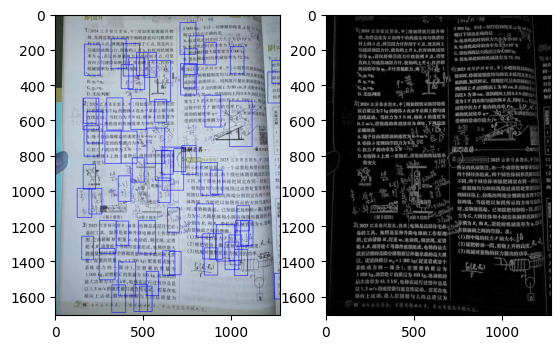

In [ ]:
"""
这段代码实现了一个简化版的HOG（Histogram of Oriented Gradients，方向梯度直方图）
方向梯度直方图特征提取算法，用于从图像中提取局部形状和边缘特征，常用于目标检测（如行人检测）和图像分类任务。

HOG 通过统计图像局部区域的梯度方向分布来描述物体形状和纹理信息，主要步骤包括：

计算梯度（方向 + 幅度）：检测图像中的边缘和纹理。
划分细胞单元（Cell）：将图像分成小块（如 8x8 像素），统计每个单元内的梯度方向直方图。
归一化块（Block）：对相邻的细胞单元组成的块（如 2x2 Cells）进行归一化，增强光照不变性。
拼接特征向量：将所有块的特征串联成最终的特征向量。

HOG（Histogram of Oriented Gradients，
方向梯度直方图）是一种基于局部形状和边缘特征的
目标检测方法，它通过统计图像中梯度方向的分布来
描述物体的轮廓和纹理信息，尤其擅长检测刚性物体
（如行人、车辆、动物等）。以下是详细解释：
"""


def extract_hog_features(image, cell_size=8, block_size=2, bins=9):
    """HOG特征提取简化版"""
    height, width = len(image), len(image[0])

    # 计算梯度
    grad_x = [[0] * width for _ in range(height)]
    grad_y = [[0] * width for _ in range(height)]
    magnitude = [[0] * width for _ in range(height)]
    orientation = [[0] * width for _ in range(height)]

    for i in range(1, height - 1):
        for j in range(1, width - 1):
            grad_x[i][j] = image[i][j + 1] - image[i][j - 1]
            grad_y[i][j] = image[i + 1][j] - image[i - 1][j]
            magnitude[i][j] = math.sqrt(grad_x[i][j] ** 2 + grad_y[i][j] ** 2)
            orientation[i][j] = math.atan2(grad_y[i][j], grad_x[i][j]) * 180 / math.pi

    # 计算细胞单元的HOG
    hog_features = []
    for i in range(0, height - cell_size + 1, cell_size):
        for j in range(0, width - cell_size + 1, cell_size):
            cell_hist = [0] * bins

            for y in range(cell_size):
                for x in range(cell_size):
                    idx_i, idx_j = i + y, j + x
                    if 0 <= idx_i < height and 0 <= idx_j < width:
                        angle = orientation[idx_i][idx_j] % 180
                        bin_idx = int(angle / (180 / bins)) % bins
                        cell_hist[bin_idx] += magnitude[idx_i][idx_j]

            # 归一化
            hist_sum = sum(cell_hist)
            if hist_sum > 0:
                cell_hist = [val / hist_sum for val in cell_hist]

            hog_features.extend(cell_hist)

    return hog_features


import math
import matplotlib.pyplot as plt
import cv2

if __name__ == "__main__":
    # cv2.HOGDescriptor

    # 读取图像
    image = cv2.imread("wen.jpg")
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    hog = cv2.HOGDescriptor()
    # 训练HOG
    hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())
    # 计算HOG特征
    (rects, weights) = hog.detectMultiScale(
        gray, winStride=(8, 8), padding=(32, 32), scale=1.05
    )

    # 绘制检测结果
    for x, y, w, h in rects:
        cv2.rectangle(image, (x, y), (x + w, y + h), (0, 0, 255), 2)

    cv2.imshow("image", image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    # ----------------------------------------

    grad_x = cv2.Sobel(gray, cv2.CV_32F, 1, 0)
    grad_y = cv2.Sobel(gray, cv2.CV_32F, 0, 1)
    magnitude, angle = cv2.cartToPolar(grad_x, grad_y, angleInDegrees=True)
    # 绘制梯度直方图
    plt.subplot(121), plt.imshow(image, cmap="gray")
    plt.subplot(122), plt.imshow(magnitude, cmap="gray")
    plt.show()

In [ ]:
# sigmoid function
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


# relu function
def relu(x):
    return np.maximum(0, x)


# tanh function
def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))


# softmax function
def softmax(x):
    return np.exp(x) / np.sum(np.exp(x), axis=0)


# cross-entropy loss function
# 交叉熵损失函数
def cross_entropy_loss(y_true, y_pred):

    return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))


# mean squared error loss function
# 均方误差损失函数
def mean_squared_error_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [ ]:
# 机器学习库
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.svm import SVC
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import numpy as np

X_train = np.array([[1, 2], [3, 4], [5, 6]])
y_train = np.array([1, 2, 3])
X_test = np.array([[7, 8], [9, 10], [11, 12]])
y_test = np.array([4, 5, 6])
X = np.vstack((X_train, X_test))
y = np.hstack((y_train, y_test))
y_true = [0, 1, 0, 1, 1]
y_pred = [0, 1, 1, 1, 0]
# 线性回归
lr = LinearRegression()
lr.fit(X_train, y_train)
predictions = lr.predict(X_test)

# 逻辑回归
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
probs = log_reg.predict_proba(X_test)

# K-means聚类
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

# PCA降维
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 数据标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 训练测试分割
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 评估指标
accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)